# 02 - Modeling

This notebook builds models to predict the numeric `stars` target for GitHub repositories.
Steps: preprocess (remove outliers, create features), train baseline models (LR, Ridge, Lasso, Decision Tree, XGBoost, SGD), evaluate with 5-fold CV, select best model by RMSE, run RFECV backward selection, refit and report metrics, and show feature importances.

In [40]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import joblib
try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None

sns.set(style="whitegrid")

In [41]:
# Load data
data_path = os.path.join('..', 'data', 'raw', 'github_repositories.csv')
df = pd.read_csv(data_path)
print('rows,cols:', df.shape)
df.head()

rows,cols: (1573, 25)


,repo_name,full_name,owner,stars,forks,watchers,open_issues,size,language,license,...,topics_count,description_length,created_at,updated_at,pushed_at,html_url,repo_age_days,days_since_update,stars_per_day,forks_to_stars_ratio
0,ML-For-Beginners,microsoft/ML-For-Beginners,microsoft,85813,20812,85813,7,2227898,Jupyter Notebook,MIT License,...,12,66,2021-03-03 01:34:05+00:00,2026-05-17 06:42:04+00:00,2026-05-08 23:43:14+00:00,https://github.com/microsoft/ML-For-Beginners,1901,0,45.117245,0.242525
1,superset,apache/superset,apache,72867,17315,72867,1265,944954,TypeScript,Apache License 2.0,...,18,69,2015-07-21 18:55:34+00:00,2026-05-17 05:26:47+00:00,2026-05-16 07:05:35+00:00,https://github.com/apache/superset,3952,0,18.433342,0.237621
2,scikit-learn,scikit-learn/scikit-learn,scikit-learn,66103,27026,66103,2022,182927,Python,"BSD 3-Clause ""New"" or ""Revised"" License",...,5,40,2010-08-17 09:43:38+00:00,2026-05-17 06:36:53+00:00,2026-05-16 15:53:37+00:00,https://github.com/scikit-learn/scikit-learn,5751,0,11.492177,0.408841
3,keras,keras-team/keras,keras-team,64072,19775,64072,187,53032,Python,Apache License 2.0,...,8,24,2015-03-28 00:35:42+00:00,2026-05-17 04:07:00+00:00,2026-05-16 01:55:29+00:00,https://github.com/keras-team/keras,4068,0,15.746375,0.308632
4,30-Days-Of-Python,Asabeneh/30-Days-Of-Python,Asabeneh,62659,11893,62659,123,30842,Python,NaN,...,15,270,2019-11-19 17:24:16+00:00,2026-05-17 06:39:52+00:00,2026-04-04 17:59:06+00:00,https://github.com/Asabeneh/30-Days-Of-Python,2370,0,26.427246,0.189802


In [42]:
# Preprocessing: create features and remove outliers
df = df.copy()
# Ensure numeric target
df = df.dropna(subset=['stars'])
df['stars'] = pd.to_numeric(df['stars'], errors='coerce')
# Boolean to int if present
for c in ['has_issues','has_projects','has_wiki','has_pages','archived']:
    if c in df.columns:
        df[c] = df[c].astype(int)
# IMPORTANT: drop 'watchers' to avoid leakage (many rows equal stars)
if 'watchers' in df.columns:
    df = df.drop(columns=['watchers'])
# Create safe derived features from forks (no target leakage)
if 'forks' in df.columns:
    if 'size' in df.columns:
        df['forks_per_size'] = df['forks'] / df['size'].replace(0, np.nan)
        df['forks_per_size'] = df['forks_per_size'].fillna(0)
    if 'repo_age_days' in df.columns:
        df['forks_per_day'] = df['forks'] / df['repo_age_days'].replace(0, np.nan)
        df['forks_per_day'] = df['forks_per_day'].fillna(0)
# Drop other leakage columns if present
for c in ['stars_per_day','forks_to_stars_ratio']:
    if c in df.columns:
        df = df.drop(columns=[c])
# Remove extreme outliers in target (above 99th percentile)
q99 = df['stars'].quantile(0.99)
print('99th percentile stars:', q99)
df = df[df['stars'] <= q99].reset_index(drop=True)
print('after outlier removal rows,cols:', df.shape)
df.describe().loc[['mean','50%','std']].T

99th percentile stars: 75090.03999999995
after outlier removal rows,cols: (1557, 24)


,mean,50%,std
stars,8724.615928,4468.000000,1.089158e+04
forks,1608.877328,704.000000,2.634650e+03
open_issues,153.899807,40.000000,3.594838e+02
size,195162.917148,30301.000000,1.406487e+06
has_issues,0.979448,1.000000,1.419256e-01
has_projects,0.843931,1.000000,3.630377e-01
has_wiki,0.748234,1.000000,4.341671e-01
has_pages,0.278741,0.000000,4.485240e-01
archived,0.055877,0.000000,2.297572e-01
topics_count,9.960822,9.000000,6.101783e+00


In [43]:
# Feature matrix
numeric_feats = [f for f in ['forks','open_issues','size','topics_count','description_length','repo_age_days','days_since_update','forks_per_size','forks_per_day'] if f in df.columns]
cat_feats = []
if 'language' in df.columns:
    top = df['language'].value_counts().index[:10]
    df['language'] = df['language'].where(df['language'].isin(top), other='Other')
    cat_feats = ['language']
X_num = df[numeric_feats].fillna(df[numeric_feats].median()) if numeric_feats else pd.DataFrame(index=df.index)
X_cat = df[cat_feats] if cat_feats else pd.DataFrame(index=df.index)
# Column transformer
transformers = []
if not X_num.empty:
    transformers.append(('num', StandardScaler(), X_num.columns.tolist()))
if not X_cat.empty:
    try:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), X_cat.columns.tolist()))
    except TypeError:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), X_cat.columns.tolist()))
preprocessor = ColumnTransformer(transformers)
# Fit preprocessor and obtain transformed X (as DataFrame with names)
X_raw = pd.concat([X_num, X_cat], axis=1)
X_trans = preprocessor.fit_transform(X_raw)
# Build feature names
feature_names = []
for name, trans, cols in transformers:
    if name == 'num':
        feature_names += cols
    else:
        ohe = preprocessor.named_transformers_[name]
        feature_names += list(ohe.get_feature_names_out(cols))
X = pd.DataFrame(X_trans, columns=feature_names)
y = df['stars'].copy()
print('Final feature matrix shape:', X.shape)
X.head()

Final feature matrix shape: (1557, 20)


,forks,open_issues,size,topics_count,description_length,repo_age_days,days_since_update,forks_per_size,forks_per_day,language_C#,language_C++,language_Go,language_HTML,language_Java,language_JavaScript,language_Jupyter Notebook,language_Other,language_Python,language_Rust,language_TypeScript
0,5.963284,3.091814,0.533266,1.317936,-0.047590,1.229423,-0.391292,-0.112188,1.558360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,9.650347,5.198288,-0.008702,-0.813273,-0.060228,2.752170,-0.391292,-0.098754,1.698517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,6.897294,0.092107,-0.101086,-0.321456,-0.067200,1.327610,-0.391292,-0.075382,1.769802,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3.904665,-0.085984,-0.116868,0.826119,0.040000,-0.109646,-0.391292,-0.074062,1.839007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,6.966776,8.657134,0.141275,-0.649334,-0.001834,2.747092,-0.391292,-0.108829,1.158489,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [54]:
# Define models
import warnings
warnings.filterwarnings('ignore')

models = {}
models['LinearRegression'] = LinearRegression()
models['RidgeCV'] = RidgeCV(alphas=np.logspace(-3,3,13), cv=5)
models['LassoCV'] = LassoCV(cv=5, max_iter=5000)
models['DecisionTree'] = DecisionTreeRegressor(random_state=42)
if XGBRegressor is not None:
    models['XGBoost'] = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
models['SGDRegressor'] = SGDRegressor(max_iter=2000, tol=1e-3, random_state=42)

# evaluate each with a pipeline that applies preprocessor then estimator
cv = KFold(n_splits=5, shuffle=True, random_state=42)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
scorers = {
    'rmse': make_scorer(rmse, greater_is_better=False),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'r2': make_scorer(r2_score)
}
results = []
for name, est in models.items():
    pipe = Pipeline([('pre', preprocessor), ('est', est)])
    try:
        rmse_scores = cross_val_score(pipe, X_raw, y, cv=cv, scoring=scorers['rmse'])
        mae_scores = cross_val_score(pipe, X_raw, y, cv=cv, scoring=scorers['mae'])
        r2_scores = cross_val_score(pipe, X_raw, y, cv=cv, scoring=scorers['r2'])
        results.append({
            'model': name,
            'rmse_mean': -rmse_scores.mean(),
            'rmse_std': rmse_scores.std(),
            'mae_mean': -mae_scores.mean(),
            'mae_std': mae_scores.std(),
            'r2_mean': r2_scores.mean(),
            'r2_std': r2_scores.std()
        })
        print(f"{name}: RMSE={-rmse_scores.mean():.3f} (+/- {rmse_scores.std():.3f}), MAE={-mae_scores.mean():.3f}, R2={r2_scores.mean():.3f}")
    except Exception as e:
        print(name, 'failed:', e)

results_df = pd.DataFrame(results).sort_values('rmse_mean')
results_df.reset_index(drop=True, inplace=True)
results_df

LinearRegression: RMSE=6719.001 (+/- 1326.427), MAE=3807.091, R2=0.608
RidgeCV: RMSE=6701.465 (+/- 1038.766), MAE=3970.628, R2=0.610
LassoCV: RMSE=6778.359 (+/- 1224.331), MAE=3868.087, R2=0.600
DecisionTree: RMSE=6855.908 (+/- 898.356), MAE=3754.388, R2=0.588
XGBoost: RMSE=5556.928 (+/- 745.281), MAE=2982.700, R2=0.730
SGDRegressor: RMSE=6688.682 (+/- 1287.380), MAE=3813.636, R2=0.612


,model,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,XGBoost,5556.927810,745.281235,2982.699707,343.357533,0.730207,0.026147
1,SGDRegressor,6688.682016,1287.379531,3813.636063,371.009257,0.611519,0.069259
2,RidgeCV,6701.464654,1038.765998,3970.627539,281.211178,0.609884,0.031828
3,LinearRegression,6719.001127,1326.426785,3807.090620,341.205581,0.607755,0.075046
4,LassoCV,6778.358858,1224.331258,3868.086868,273.055058,0.600115,0.064514
5,DecisionTree,6855.908109,898.355842,3754.387839,496.074893,0.588175,0.044922


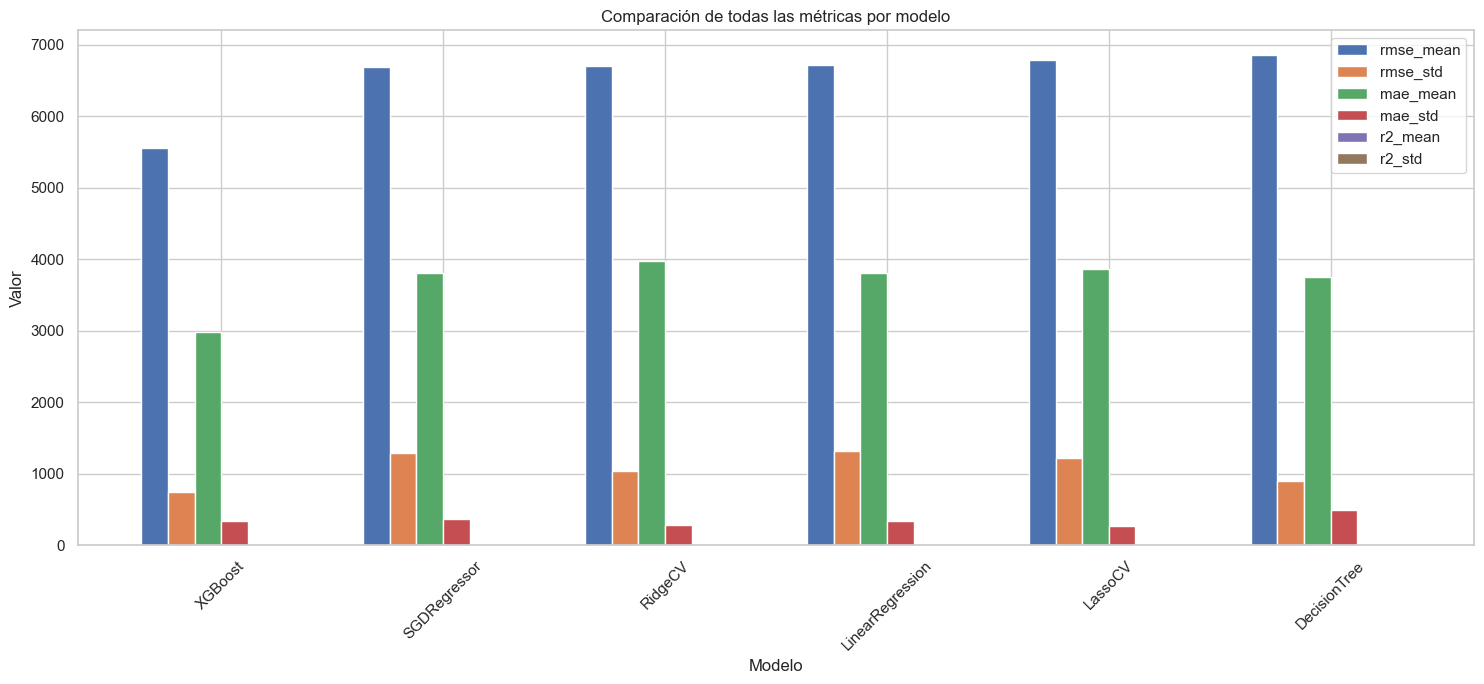

In [53]:
models_names = results_df['model']

# Métricas
metrics = [
    'rmse_mean',
    'rmse_std',
    'mae_mean',
    'mae_std',
    'r2_mean',
    'r2_std'
]

# Posiciones
x = np.arange(len(models_names))
width = 0.12

# Figura
plt.figure(figsize=(15,7))

# Graficar cada métrica
for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width,
        results_df[metric],
        width,
        label=metric
    )

# Ajustes
plt.xticks(
    x + width * (len(metrics)-1)/2,
    models_names,
    rotation=45
)

plt.ylabel('Valor')
plt.xlabel('Modelo')
plt.title('Comparación de todas las métricas por modelo')

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Select best model by RMSE and run RFECV for backward selection
best_name = results_df.loc[0,'model']
print('Best baseline model:', best_name)
best_est = models[best_name]
# Transform full feature matrix once
X_full = preprocessor.transform(X_raw)
feature_names = X.columns.tolist()
# RFECV (use estimator without pipeline)
try:
    rfecv = RFECV(estimator=best_est, step=1, cv=cv, scoring=make_scorer(rmse, greater_is_better=False), n_jobs=-1)
    rfecv.fit(X_full, y)
    support = rfecv.support_
    selected_features = [f for f, s in zip(feature_names, support) if s]
    print('Number of selected features:', len(selected_features))
    print(selected_features)
    # Refit estimator on selected features
    X_sel = pd.DataFrame(X_full, columns=feature_names)[selected_features]
    # If estimator needs scaling or not, best_est is a fresh estimator; fit on selected
    best_est.fit(X_sel, y)
    # Evaluate with cross-val using a pipeline that selects the same columns then estimator
    # We'll wrap with a small transformer to select columns from preprocessor output when evaluating from raw X_raw
    from sklearn.base import TransformerMixin, BaseEstimator
    class ColumnSelector(TransformerMixin, BaseEstimator):
        def __init__(self, cols):
            self.cols = cols
        def fit(self, X, y=None):
            return self
        def transform(self, X):
            # X will be the preprocessor output array
            Xdf = pd.DataFrame(X, columns=feature_names)
            return Xdf[self.cols].values

    sel_pipe = Pipeline([('pre', preprocessor), ('sel', ColumnSelector(selected_features)), ('est', best_est)])
    rmse_scores = cross_val_score(sel_pipe, X_raw, y, cv=cv, scoring=scorers['rmse'])
    mae_scores = cross_val_score(sel_pipe, X_raw, y, cv=cv, scoring=scorers['mae'])
    r2_scores = cross_val_score(sel_pipe, X_raw, y, cv=cv, scoring=scorers['r2'])
    print('After RFECV - RMSE:', -rmse_scores.mean(), 'MAE:', -mae_scores.mean(), 'R2:', r2_scores.mean())
    final_pipe = sel_pipe
except Exception as e:
    print('RFECV failed:', e)
    # fallback: final_pipe is pipeline with preprocessor and the baseline estimator
    final_pipe = Pipeline([('pre', preprocessor), ('est', models[best_name])])
    final_pipe.fit(X_raw, y)

# Save final model
os.makedirs(os.path.join('..','models'), exist_ok=True)
joblib.dump(final_pipe, os.path.join('..','models','best_model.pkl'))
print('Saved model to ../models/best_model.pkl')

Best baseline model: XGBoost
Number of selected features: 17
['forks', 'open_issues', 'size', 'topics_count', 'description_length', 'repo_age_days', 'days_since_update', 'forks_per_day', 'language_C++', 'language_Go', 'language_HTML', 'language_Java', 'language_JavaScript', 'language_Jupyter Notebook', 'language_Other', 'language_Rust', 'language_TypeScript']
After RFECV - RMSE: 5560.121991476846 MAE: 2973.550146484375 R2: 0.7312180399894714
Saved model to ../models/best_model.pkl


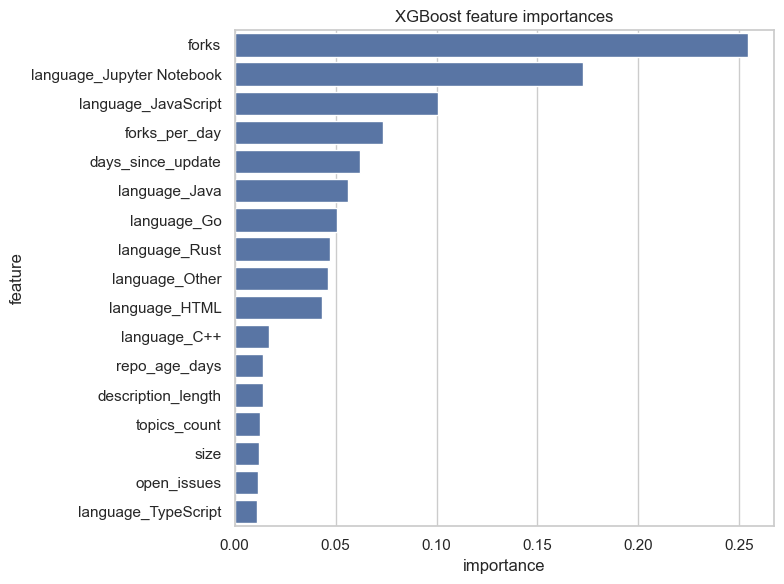

{'forks': np.float32(0.25442222),
 'open_issues': np.float32(0.011711585),
 'size': np.float32(0.012213975),
 'topics_count': np.float32(0.012438533),
 'description_length': np.float32(0.013830215),
 'repo_age_days': np.float32(0.0140569415),
 'days_since_update': np.float32(0.06211271),
 'forks_per_size': np.float32(0.07369451),
 'forks_per_day': np.float32(0.017189361),
 'language_C#': np.float32(0.05057586),
 'language_C++': np.float32(0.04346643),
 'language_Go': np.float32(0.05599254),
 'language_HTML': np.float32(0.100838855),
 'language_Java': np.float32(0.17260095),
 'language_JavaScript': np.float32(0.046345513),
 'language_Jupyter Notebook': np.float32(0.047420554),
 'language_Other': np.float32(0.011089201)}

In [55]:
# Feature importances / coefficients
def plot_importances(names, importances, title='Feature importances'):
    imp_df = pd.DataFrame({'feature': names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).head(30)
    plt.figure(figsize=(8,6))
    sns.barplot(data=imp_df, x='importance', y='feature')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Try to extract importances from the underlying estimator in final pipeline
est = final_pipe.named_steps.get('est', None)
if est is None:
    print('No estimator found in final pipeline')
else:
    # If tree-based
    if hasattr(est, 'feature_importances_'):
        importances = est.feature_importances_
        plot_importances(selected_features if 'selected_features' in globals() else feature_names, importances, title=f'{best_name} feature importances')
    # If linear
    elif hasattr(est, 'coef_'):
        coefs = est.coef_.ravel() if getattr(est, 'coef_', None) is not None else np.zeros(len(feature_names))
        plot_importances(selected_features if 'selected_features' in globals() else feature_names, np.abs(coefs), title=f'{best_name} abs(coefficients)')
    else:
        print('Estimator has no attribute for importances/coefs')

features = dict(zip(feature_names, importances))
display(features)



In [ ]:
len(features)

17

## Next steps
- Review metrics and selected features above.
- Optionally tune hyperparameters for the chosen estimator (GridSearchCV / RandomizedSearchCV).
- Consider log-transforming `stars` if residuals are skewed.
- Ask if you want plots or additional diagnostics added.

In [ ]:
# 2) RFECV backward selection (re-run) and ranking
from sklearn.feature_selection import RFECV

# ensure variables exist
if 'best_name' not in globals():
    best_name = results_df.loc[0, 'model']
    print('Derived best_name:', best_name)

best_est = models[best_name]
X_full = preprocessor.transform(X_raw)
feature_names = X.columns.tolist()

rfecv_final = RFECV(estimator=best_est, step=1, cv=cv, scoring=make_scorer(rmse, greater_is_better=False), n_jobs=-1)
rfecv_final.fit(X_full, y)
support = rfecv_final.support_
selected_features = [f for f, s in zip(feature_names, support) if s]
print(f'RFECV selected {len(selected_features)} features:')
print(selected_features)

rank_df = pd.DataFrame({'feature': feature_names, 'rank': rfecv_final.ranking_, 'support': support})
rank_df = rank_df.sort_values('rank')
display(rank_df)


RFECV selected 17 features:
['forks', 'open_issues', 'size', 'topics_count', 'description_length', 'repo_age_days', 'days_since_update', 'forks_per_day', 'language_C++', 'language_Go', 'language_HTML', 'language_Java', 'language_JavaScript', 'language_Jupyter Notebook', 'language_Other', 'language_Rust', 'language_TypeScript']


,feature,rank,support
0,forks,1,True
16,language_Other,1,True
15,language_Jupyter Notebook,1,True
14,language_JavaScript,1,True
13,language_Java,1,True
12,language_HTML,1,True
11,language_Go,1,True
10,language_C++,1,True
18,language_Rust,1,True
19,language_TypeScript,1,True


In [56]:
# 3) Bayesian hyperparameter tuning with Optuna and final fit/save
# install optuna if not present
%pip install --quiet optuna
import optuna
from sklearn.base import TransformerMixin, BaseEstimator

class ColumnSelector(TransformerMixin, BaseEstimator):
    def __init__(self, cols, feature_names=feature_names):
        self.cols = cols
        self.feature_names = feature_names
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        Xdf = pd.DataFrame(X, columns=self.feature_names)
        return Xdf[self.cols].values

# objective returning CV RMSE (to minimize)
def make_objective(best_name, selected_features):
    def objective(trial):
        # choose estimator and hyperparameter search space
        if best_name == 'XGBoost' and XGBRegressor is not None:
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 400),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
            }
            est = XGBRegressor(**params, random_state=42, verbosity=0)
        elif best_name == 'DecisionTree':
            params = {
                'max_depth': trial.suggest_int('max_depth', 2, 30),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50)
            }
            est = DecisionTreeRegressor(**params, random_state=42)
        elif best_name == 'SGDRegressor':
            params = {
                'alpha': trial.suggest_float('alpha', 1e-6, 1e-1, log=True)
            }
            est = SGDRegressor(max_iter=5000, tol=1e-4, random_state=42, **params)
        elif best_name in ('LassoCV','RidgeCV'):
            alpha = trial.suggest_float('alpha', 1e-6, 1e2, log=True)
            if best_name == 'RidgeCV':
                from sklearn.linear_model import Ridge
                est = Ridge(alpha=alpha)
            else:
                from sklearn.linear_model import Lasso
                est = Lasso(alpha=alpha, max_iter=5000)
        else:
            est = LinearRegression()

        sel = ColumnSelector(selected_features)
        pipe = Pipeline([('pre', preprocessor), ('sel', sel), ('est', est)])
        scores = cross_val_score(pipe, X_raw, y, cv=cv, scoring=make_scorer(rmse, greater_is_better=False), n_jobs=-1)
        rmse_val = -scores.mean()
        return rmse_val
    return objective

# prepare selected_features fallback
if 'selected_features' not in globals() or not selected_features:
    selected_features = feature_names
    print('No RFECV selection found, using all features')

study = optuna.create_study(direction='minimize')
study.optimize(make_objective(best_name, selected_features), n_trials=40, n_jobs=1)
print('Best CV RMSE (study):', study.best_value)
print('Best params:', study.best_trial.params)

# build final estimator from best params
best_params = study.best_trial.params
if best_name == 'XGBoost' and XGBRegressor is not None:
    final_est = XGBRegressor(**best_params, random_state=42, verbosity=0)
elif best_name == 'DecisionTree':
    final_est = DecisionTreeRegressor(**best_params, random_state=42)
elif best_name == 'SGDRegressor':
    final_est = SGDRegressor(max_iter=5000, tol=1e-4, random_state=42, **best_params)
elif best_name in ('LassoCV','RidgeCV'):
    if best_name == 'RidgeCV':
        from sklearn.linear_model import Ridge
        final_est = Ridge(**best_params)
    else:
        from sklearn.linear_model import Lasso
        final_est = Lasso(max_iter=5000, **best_params)
else:
    final_est = LinearRegression()

# fit final pipeline
final_pipe = Pipeline([('pre', preprocessor), ('sel', ColumnSelector(selected_features)), ('est', final_est)])
final_pipe.fit(X_raw, y)

# evaluate final with CV
final_scores = cross_val_score(final_pipe, X_raw, y, cv=cv, scoring=make_scorer(rmse, greater_is_better=False), n_jobs=-1)
print('Final tuned CV RMSE:', -final_scores.mean(), '+/-', final_scores.std())

# save
os.makedirs(os.path.join('..','models'), exist_ok=True)
joblib.dump(final_pipe, os.path.join('..','models','best_model_optuna.pkl'))
print('Saved tuned model to ../models/best_model_optuna.pkl')


You should consider upgrading via the '/Users/carlosangel50/projects/proyecto_final_ml/venv/bin/python -m pip install --upgrade pip' command.


[I 2026-05-21 20:21:18,138] A new study created in memory with name: no-name-c9a7ed9e-b92f-4308-917b-d34ab8d39f6c


Note: you may need to restart the kernel to use updated packages.


[I 2026-05-21 20:21:19,992] Trial 0 finished with value: 5253.039128489791 and parameters: {'n_estimators': 296, 'max_depth': 9, 'learning_rate': 0.010671706690317943, 'subsample': 0.8378550204697945, 'colsample_bytree': 0.7854177651629901}. Best is trial 0 with value: 5253.039128489791.
[I 2026-05-21 20:21:21,586] Trial 1 finished with value: 5350.451217666137 and parameters: {'n_estimators': 307, 'max_depth': 12, 'learning_rate': 0.12815032952412828, 'subsample': 0.8955081500875074, 'colsample_bytree': 0.7811849660584844}. Best is trial 0 with value: 5253.039128489791.
[I 2026-05-21 20:21:22,512] Trial 2 finished with value: 5300.309620180223 and parameters: {'n_estimators': 167, 'max_depth': 10, 'learning_rate': 0.09355577746554185, 'subsample': 0.9521150993110116, 'colsample_bytree': 0.5712180604980721}. Best is trial 0 with value: 5253.039128489791.
[I 2026-05-21 20:21:23,322] Trial 3 finished with value: 5506.088605808747 and parameters: {'n_estimators': 57, 'max_depth': 11, 'lea

Best CV RMSE (study): 5100.674044219164
Best params: {'n_estimators': 298, 'max_depth': 5, 'learning_rate': 0.010615777641843837, 'subsample': 0.9413526573209795, 'colsample_bytree': 0.8233121241776147}
Final tuned CV RMSE: 5100.674044219164 +/- 619.7650317894015
Saved tuned model to ../models/best_model_optuna.pkl


In [57]:
# --- Analysis of final tuned model (best_model_optuna.pkl)
import os
import joblib

# Define ColumnSelector to allow unpickling if present inside pipeline
class ColumnSelector(TransformerMixin, BaseEstimator):
    def __init__(self, cols, feature_names=None):
        self.cols = cols
        self.feature_names = feature_names
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if isinstance(X, (np.ndarray, list)):
            if self.feature_names is None:
                raise ValueError('feature_names must be provided when transforming numpy arrays')
            Xdf = pd.DataFrame(X, columns=self.feature_names)
        else:
            Xdf = pd.DataFrame(X)
        return Xdf[self.cols].values

# Load final tuned model
model_path = os.path.join('..','models','best_model_optuna.pkl')
if not os.path.exists(model_path):
    raise FileNotFoundError(f'Model not found: {model_path}')
model = joblib.load(model_path)
print('Loaded model from', model_path)
print('Model type:', type(model))

# Load and apply the same preprocessing used earlier in the notebook
data_path = os.path.join('..','data','raw','github_repositories.csv')
df_full = pd.read_csv(data_path).copy()
# Ensure numeric target and basic cleaning
df_full = df_full.dropna(subset=['stars'])
df_full['stars'] = pd.to_numeric(df_full['stars'], errors='coerce')
for c in ['has_issues','has_projects','has_wiki','has_pages','archived']:
    if c in df_full.columns:
        try:
            df_full[c] = df_full[c].astype(int)
        except Exception:
            pass
# Drop watchers to avoid leakage
if 'watchers' in df_full.columns:
    df_full = df_full.drop(columns=['watchers'])
# Derived forks features
if 'forks' in df_full.columns:
    if 'size' in df_full.columns:
        df_full['forks_per_size'] = df_full['forks'] / df_full['size'].replace(0, np.nan)
        df_full['forks_per_size'] = df_full['forks_per_size'].fillna(0)
    if 'repo_age_days' in df_full.columns:
        df_full['forks_per_day'] = df_full['forks'] / df_full['repo_age_days'].replace(0, np.nan)
        df_full['forks_per_day'] = df_full['forks_per_day'].fillna(0)
# Drop other leakage columns if present
for c in ['stars_per_day','forks_to_stars_ratio']:
    if c in df_full.columns:
        df_full = df_full.drop(columns=[c])
# Remove extreme outliers in target (above 99th percentile)
q99 = df_full['stars'].quantile(0.99)
df = df_full[df_full['stars'] <= q99].reset_index(drop=True)
print('Data for evaluation rows,cols:', df.shape)

# Recreate feature matrix used earlier (X_raw)
numeric_feats = [f for f in ['forks','open_issues','size','topics_count','description_length','repo_age_days','days_since_update','forks_per_size','forks_per_day'] if f in df.columns]
cat_feats = []
if 'language' in df.columns:
    top = df['language'].value_counts().index[:10]
    df['language'] = df['language'].where(df['language'].isin(top), other='Other')
    cat_feats = ['language']
X_num = df[numeric_feats].fillna(df[numeric_feats].median()) if numeric_feats else pd.DataFrame(index=df.index)
X_cat = df[cat_feats] if cat_feats else pd.DataFrame(index=df.index)
X_raw = pd.concat([X_num, X_cat], axis=1)
print('Prepared X_raw shape for evaluation:', X_raw.shape)

# Predict using the loaded model (pipeline handles preprocessing/selection internally)
try:
    preds = model.predict(X_raw)
except Exception as e:
    # fallback: if pipeline has 'pre' and 'est' steps, apply manually
    if hasattr(model, 'named_steps') and 'pre' in model.named_steps and 'est' in model.named_steps:
        pre = model.named_steps['pre']
        est = model.named_steps['est']
        X_pre = pre.transform(X_raw)
        preds = est.predict(X_pre)
    else:
        raise

# Compute metrics
y = df['stars'].values
residuals = y - preds
rmse = np.sqrt(mean_squared_error(y, preds))
mae = mean_absolute_error(y, preds)
r2 = r2_score(y, preds)
res_std = np.std(residuals)
print('', flush=True)
print('Evaluation metrics:')
print(f'  n = {len(y)}')
print(f'  RMSE = {rmse:.3f}')
print(f'  MAE  = {mae:.3f}')
print(f'  R2   = {r2:.4f}')
print(f'  residual std = {res_std:.3f}')

# Build comparison DataFrame for plotting and inspection
comp = df[[c for c in ['repo_name','owner'] if c in df.columns]].copy()
comp = comp.assign(actual=y, pred=preds)
comp['residual'] = comp['actual'] - comp['pred']
comp['abs_residual'] = comp['residual'].abs()
comp['pct_error'] = comp['abs_residual'] / (comp['actual'].replace(0, np.nan)) * 100

# Save CSV of comparisons
os.makedirs('report', exist_ok=True)
out_csv = os.path.join('report','predictions_vs_actual_optuna_analysis.csv')
comp.to_csv(out_csv, index=False)
print('Saved comparison CSV to', out_csv)

# Expose variables for next cell
_analysis = {'y': y, 'preds': preds, 'residuals': residuals, 'rmse': rmse, 'mae': mae, 'r2': r2, 'res_std': res_std, 'comp': comp}


Loaded model from ../models/best_model_optuna.pkl
Model type: <class 'sklearn.pipeline.Pipeline'>
Data for evaluation rows,cols: (1557, 24)
Prepared X_raw shape for evaluation: (1557, 10)

Evaluation metrics:
  n = 1557
  RMSE = 3153.124
  MAE  = 1889.068
  R2   = 0.9161
  residual std = 3153.009
Saved comparison CSV to report/predictions_vs_actual_optuna_analysis.csv


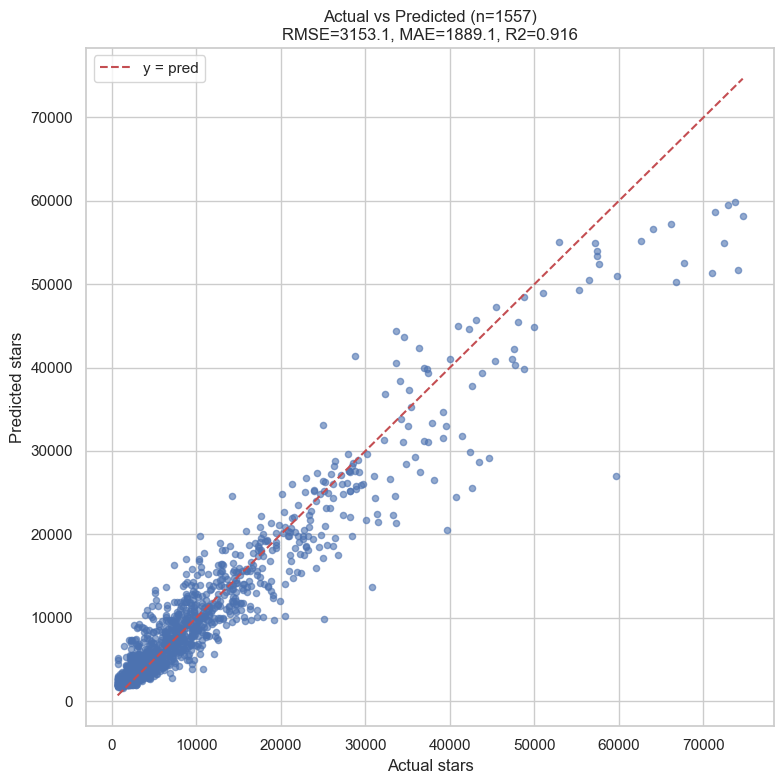

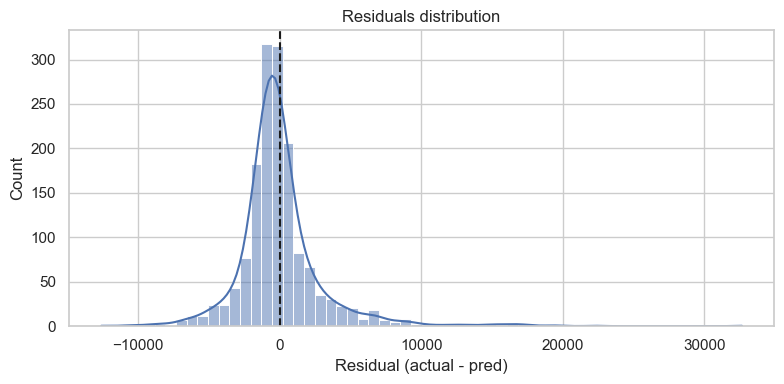

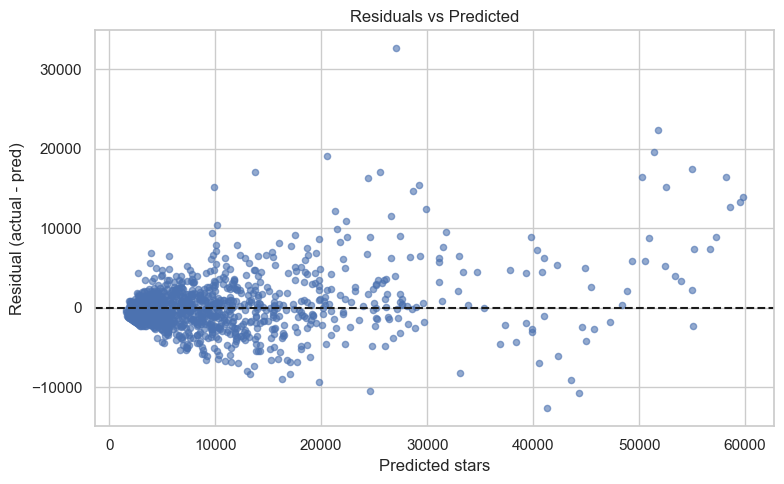

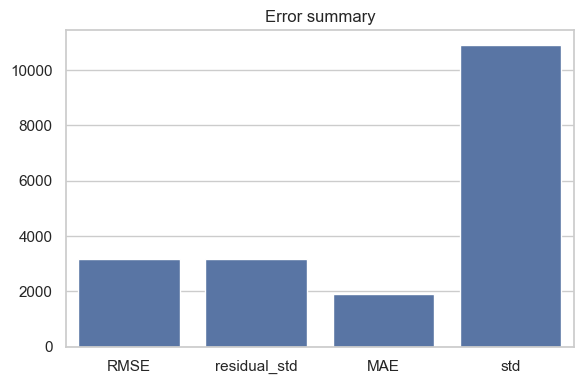

,repo_name,owner,actual,pred,residual,abs_residual,pct_error
304,llm-app,pathwaycom,59712,27056.333984,32655.666016,32655.666016,54.688615
299,tesseract,tesseract-ocr,74122,51759.539062,22362.460938,22362.460938,30.169802
301,awesome-scalability,binhnguyennus,71052,51372.281250,19679.718750,19679.718750,27.697628
316,photoprism,photoprism,39675,20554.039062,19120.960938,19120.960938,48.193978
300,awesome-machine-learning,josephmisiti,72489,54954.679688,17534.320312,17534.320312,24.188939
330,DeepFaceLive,iperov,30841,13746.833008,17094.166992,17094.166992,55.426760
9,gradio,gradio-app,42610,25520.207031,17089.792969,17089.792969,40.107470
303,annotated_deep_learning_paper_implementations,labmlai,66744,50247.445312,16496.554688,16496.554688,24.716161
527,Prompt-Engineering-Guide,dair-ai,74651,58224.125000,16426.875000,16426.875000,22.004896
315,paperless-ngx,paperless-ngx,40750,24441.605469,16308.394531,16308.394531,40.020600


Saved last plot to report/figures/last_plot.png


<Figure size 640x480 with 0 Axes>

In [60]:
# Plots for the final tuned model: residuals, actual vs pred, RMSE vs residual std
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
y = _analysis['y']
preds = _analysis['preds']
residuals = _analysis['residuals']
rmse = _analysis['rmse']
mae = _analysis['mae']
r2 = _analysis['r2']
res_std = _analysis['res_std']
comp = _analysis['comp']
std = df['stars'].std() if 'stars' in df.columns else np.std(y)

# 1) Scatter actual vs predicted
plt.figure(figsize=(8,8))
plt.scatter(y, preds, alpha=0.6, s=20)
lims = [min(y.min(), preds.min()), max(y.max(), preds.max())]
plt.plot(lims, lims, 'r--', label='y = pred')
plt.xlabel('Actual stars')
plt.ylabel('Predicted stars')
plt.title(f'Actual vs Predicted (n={len(y)})\nRMSE={rmse:.1f}, MAE={mae:.1f}, R2={r2:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

# 2) Residuals histogram + KDE
plt.figure(figsize=(8,4))
sns.histplot(residuals, bins=60, kde=True)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Residual (actual - pred)')
plt.title('Residuals distribution')
plt.tight_layout()
plt.show()

# 3) Residuals vs Predicted (to spot heteroscedasticity)
plt.figure(figsize=(8,5))
plt.scatter(preds, residuals, alpha=0.6, s=20)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Predicted stars')
plt.ylabel('Residual (actual - pred)')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.show()

# 4) Simple bar: RMSE vs residual std vs MAE
plt.figure(figsize=(6,4))
vals = [rmse, res_std, mae, std]
labels = ['RMSE','residual_std','MAE', 'std']
sns.barplot(x=labels, y=vals)
plt.title('Error summary')
plt.tight_layout()
plt.show()

# 5) Show top examples with largest absolute error
display(comp.sort_values('abs_residual', ascending=False).head(10))

# Save figures to report/figures
os.makedirs(os.path.join('report','figures'), exist_ok=True)
plt.savefig(os.path.join('report','figures','last_plot.png'))
print('Saved last plot to report/figures/last_plot.png')
